In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 한글 폰트 설정 (필요한 경우)
# plt.rcParams['font.family'] = 'AppleGothic'  # macOS
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 데이터 정의
# 공통 부분
common_tasks = [
    {'name': 'Node Preparation', 'duration': 41.5, 'start': 0},
]

# 분기 후 작업들 (51.5s 부터 시작)
split_start = 47.5
gap_duration = 7.1  # 47.5 ~ 51.5

bar1_split_tasks = [
    {'name': 'Load Tensor Store', 'duration': 61.8},
]

bar2_split_tasks = [
    {'name': 'Init. Inference Engine', 'duration': 64.5} 
]

# 색상 정의
colors = {
    'Node Preparation': '#4A90E2',
    # 'Init. Cluster': '#7B68EE',
    'Load Tensor Store': '#50C878',
    'Init. Inference Engine': '#E67E22'
}

# Hatch 패턴 정의 (간격 넓게)
hatches = {
    'Node Preparation': '/',
    # 'Init. Cluster': '\\',
    'Load Tensor Store': '\\',
    'Init. Inference Engine': 'x'
}

# 폰트 크기 통일
FONT_SIZE = 30

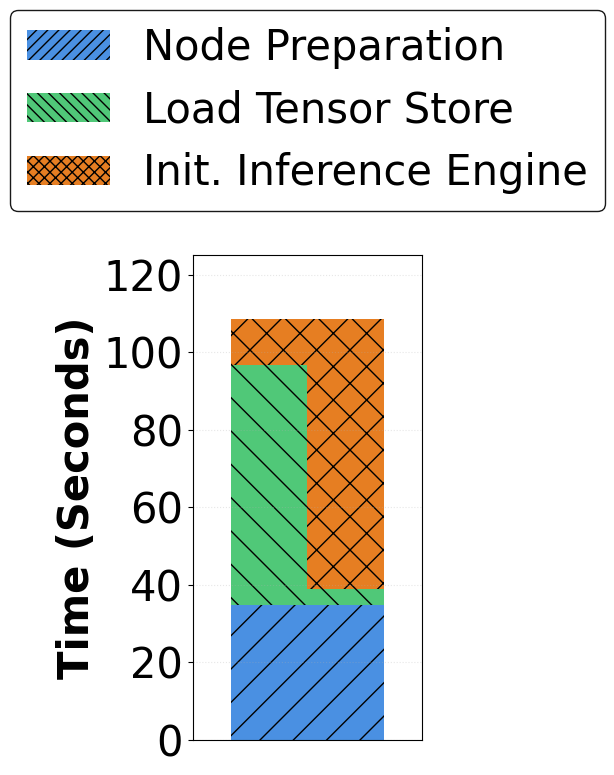

In [ ]:
# 그래프 생성
fig, ax = plt.subplots(figsize=(5, 9))

bar_width = 0.4
x_positions = [-0.2, 0.2]

# 1. 공통 부분 그리기 (양쪽 모두 - 테두리 없음)
bottom = 0
for i, task in enumerate(common_tasks):
    # 왼쪽 bar
    bars1 = ax.bar(x_positions[0], task['duration'], width=bar_width, bottom=bottom,
                   color=colors[task['name']], )
    bars1[0].set_hatch(hatches[task['name']])
    
    # 오른쪽 bar (같은 색상, 테두리 없음)
    bars2 = ax.bar(x_positions[1], task['duration'], width=bar_width, bottom=bottom,
                   color=colors[task['name']], )
    bars2[0].set_hatch(hatches[task['name']])
    
    bottom += task['duration']

# 2. Gap 부분 (47.5 ~ 51.5) - Load Tensor Store 색상으로 채우기
# 왼쪽 bar
bars3 = ax.bar(x_positions[0], gap_duration, width=bar_width, bottom=bottom,
               color=colors['Load Tensor Store'])
bars3[0].set_hatch(hatches['Load Tensor Store'])
# 오른쪽 bar (같은 색상)
bars4 = ax.bar(x_positions[1], gap_duration, width=bar_width, bottom=bottom,
               color=colors['Load Tensor Store'])
bars4[0].set_hatch(hatches['Load Tensor Store'])

bottom += gap_duration  # 이제 51.5

# 3. 분기 후 작업 그리기
# Bar 1 (왼쪽): Load Tensor Store 계속
remaining_tensor = bar1_split_tasks[0]['duration'] - gap_duration
bars5 = ax.bar(x_positions[0], remaining_tensor, width=bar_width, bottom=bottom,
               color=colors['Load Tensor Store'])
bars5[0].set_hatch(hatches['Load Tensor Store'])

# Bar 1 (왼쪽): Load Tensor Store 위에 Init. Inference Engine 추가
left_bottom_inference = bottom + remaining_tensor  # 96.6
left_inference_duration = bar2_split_tasks[0]['duration'] - remaining_tensor  # 118.7 - 96.6 = 22.1
bars7 = ax.bar(x_positions[0], left_inference_duration, width=bar_width, bottom=left_bottom_inference,
               color=colors['Init. Inference Engine'])
bars7[0].set_hatch(hatches['Init. Inference Engine'])

# Bar 2 (오른쪽): Init. Inference Engine
bars6 = ax.bar(x_positions[1], bar2_split_tasks[0]['duration'], width=bar_width, bottom=bottom,
               color=colors['Init. Inference Engine'])
bars6[0].set_hatch(hatches['Init. Inference Engine'])

# # 주요 시간 표시
# key_times = [34.8, 47.5, 51.5, 96.6, 118.7]
# for time in key_times:
#     ax.axhline(y=time, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
#     ax.text(-0.5, time, f'{time}s', va='center', fontsize=FONT_SIZE, ha='right')

# 축 설정
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 125)
ax.set_yticks(range(0, 130, 20))
ax.set_ylabel('Time (Seconds)', fontsize=FONT_SIZE)
ax.set_xticks([])

# y축 tick fontsize 설정
ax.tick_params(axis='y', labelsize=FONT_SIZE)

# 범례 추가 (그래프 상단 바깥쪽, hatch 촘촘하게)
legend_elements = [
    mpatches.Patch(facecolor=colors['Node Preparation'], hatch='///', label='Node Preparation'),
    # mpatches.Patch(facecolor=colors['Init. Cluster'], hatch='\\\\\\', label='Init. Cluster'),
    mpatches.Patch(facecolor=colors['Load Tensor Store'], hatch='\\\\\\', label='Load Tensor Store'),
    mpatches.Patch(facecolor=colors['Init. Inference Engine'], hatch='xxx', label='Init. Inference Engine')
]
# ax.legend(handles=legend_elements, loc='right', bbox_to_anchor=(2.43, 0.5),
        #   fontsize=FONT_SIZE, framealpha=0.9, ncol=1, edgecolor='black')
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.55), 
          fontsize=FONT_SIZE, framealpha=0.9, ncol=1, edgecolor='black')
# 그리드 추가
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig("node_replacement_timeline.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

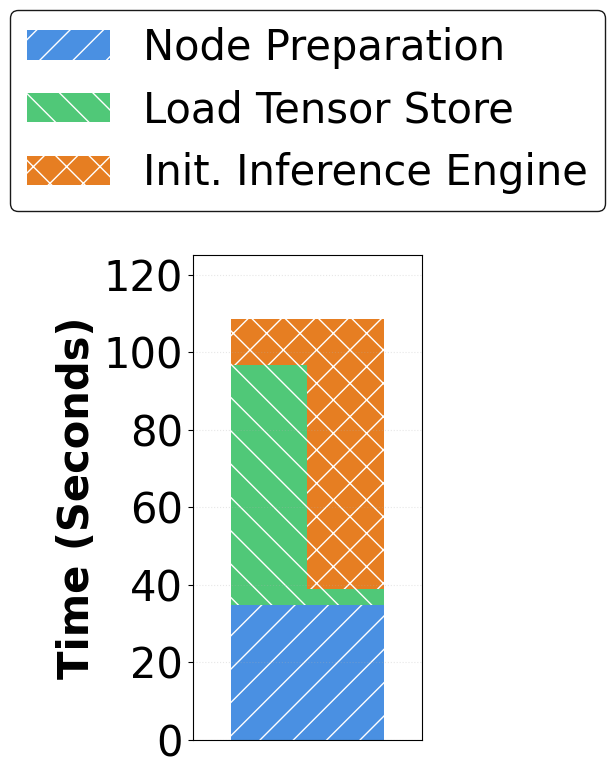

In [ ]:
fig, ax = plt.subplots(figsize=(5, 9))

bar_width = 0.4
x_positions = [-0.2, 0.2]

# 1. 공통 부분
bottom = 0
for i, task in enumerate(common_tasks):
    # 왼쪽 bar
    bars1 = ax.bar(
        x_positions[0],
        task['duration'],
        width=bar_width,
        bottom=bottom,
        color=colors[task['name']],
        edgecolor='white',
        linewidth=0
    )
    bars1[0].set_hatch(hatches[task['name']])
    
    # 오른쪽 bar
    bars2 = ax.bar(
        x_positions[1],
        task['duration'],
        width=bar_width,
        bottom=bottom,
        color=colors[task['name']],
        edgecolor='white',
        linewidth=0
    )
    bars2[0].set_hatch(hatches[task['name']])
    
    bottom += task['duration']

# 2. Gap (Load Tensor Store 색으로)
bars3 = ax.bar(
    x_positions[0],
    gap_duration,
    width=bar_width,
    bottom=bottom,
    color=colors['Load Tensor Store'],
    edgecolor='white',
    linewidth=0
)
bars3[0].set_hatch(hatches['Load Tensor Store'])

bars4 = ax.bar(
    x_positions[1],
    gap_duration,
    width=bar_width,
    bottom=bottom,
    color=colors['Load Tensor Store'],
    edgecolor='white',
    linewidth=0
)
bars4[0].set_hatch(hatches['Load Tensor Store'])

bottom += gap_duration  # 이제 51.5

# 3. 분기 이후
# 왼쪽: Load Tensor Store 계속
remaining_tensor = bar1_split_tasks[0]['duration'] - gap_duration
bars5 = ax.bar(
    x_positions[0],
    remaining_tensor,
    width=bar_width,
    bottom=bottom,
    color=colors['Load Tensor Store'],
    edgecolor='white',
    linewidth=0
)
bars5[0].set_hatch(hatches['Load Tensor Store'])

# 왼쪽: 그 위에 Init. Inference Engine
left_bottom_inference = bottom + remaining_tensor  # 96.6
left_inference_duration = bar2_split_tasks[0]['duration'] - remaining_tensor  # 22.1
bars7 = ax.bar(
    x_positions[0],
    left_inference_duration,
    width=bar_width,
    bottom=left_bottom_inference,
    color=colors['Init. Inference Engine'],
    edgecolor='white',
    linewidth=0
)
bars7[0].set_hatch(hatches['Init. Inference Engine'])

# 오른쪽: Init. Inference Engine
bars6 = ax.bar(
    x_positions[1],
    bar2_split_tasks[0]['duration'],
    width=bar_width,
    bottom=bottom,
    color=colors['Init. Inference Engine'],
    edgecolor='white',
    linewidth=0
)
bars6[0].set_hatch(hatches['Init. Inference Engine'])

# 축 설정
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 125)
ax.set_yticks(range(0, 130, 20))
ax.set_ylabel('Time (Seconds)', fontsize=FONT_SIZE)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=FONT_SIZE)

# 범례 (해치도 흰색으로)
legend_elements = [
    mpatches.Patch(
        facecolor=colors['Node Preparation'],
        hatch='/',
        edgecolor='white',
        linewidth=0,
        label='Node Preparation'
    ),
    # mpatches.Patch(
    #     facecolor=colors['Init. Cluster'],
    #     hatch='\\',
    #     edgecolor='white',
    #     linewidth=0,
    #     label='Init. Cluster'
    # ),
    mpatches.Patch(
        facecolor=colors['Load Tensor Store'],
        hatch='\\',
        edgecolor='white',
        linewidth=0,
        label='Load Tensor Store'
    ),
    mpatches.Patch(
        facecolor=colors['Init. Inference Engine'],
        hatch='x',
        edgecolor='white',
        linewidth=0,
        label='Init. Inference Engine'
    )
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.55),
    fontsize=FONT_SIZE,
    framealpha=0.9,
    ncol=1,
    edgecolor='black'
)

ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig("node_replacement_timeline.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()


In [5]:
# 그래프를 파일로 저장
# fig.savefig('timeline_stacked_bar.png', dpi=300, bbox_inches='tight')